# Notebook 07 — Full End-to-End Pipeline Demo

**EvaliSense: AI-Powered Handwritten Examination Evaluation with ML-Based Grading Error Prediction**

---

## Objective

This notebook demonstrates the **complete** evaluation pipeline from raw answer sheet image to examiner review.

```
 ┌──────────────────────────────────────────────────────────────────────┐
 │ Handwritten Image  →  Preprocess  →  Segment Lines  →  TrOCR HTR  │
 │     →  Rubric Evaluation  →  Feature Extraction  →  Risk Model    │
 │          →  Risk Alert  →  Examiner Review  →  Ground Truth        │
 └──────────────────────────────────────────────────────────────────────┘
```

We will:
1. Load all pipeline components
2. Run the full pipeline on a test answer sheet
3. Display step-by-step outputs at each stage
4. Generate a summary visualization
5. Print timing breakdown
6. Simulate examiner review and error recording

**Why this matters:** This notebook proves the entire system works end-to-end. Every prior notebook explored a single component — here we assemble the complete product.

## Setup

In [1]:
import os, sys, warnings, time, json
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import config

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

RESULTS_DIR = config.results_dir
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print("Setup complete ✓")

Project root: C:\Users\ASUS\Documents\projects\EvaliSense
Setup complete ✓


## Step 1: Select Input Image

Input: answer_photosynthesis_good.png
Shape: (3508, 2480, 3)
Size: 24.9 MB


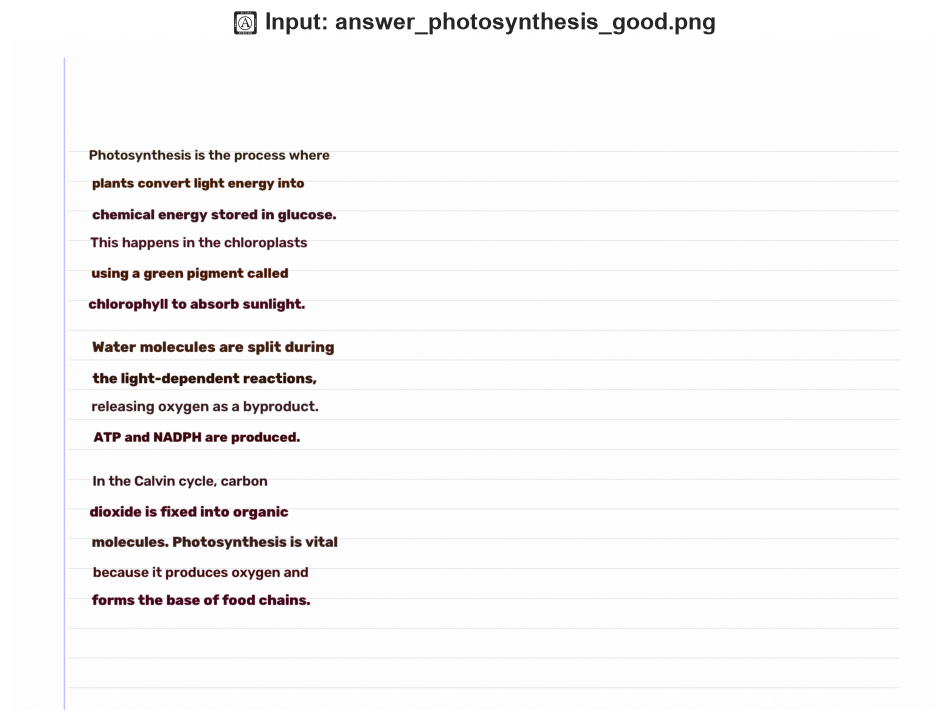

In [2]:
# Find a test image
image_path = None
for candidate in ['answer_photosynthesis_good.png', 'answer_photosynthesis_partial.png']:
    p = config.raw_dir / candidate
    if p.exists():
        image_path = p
        break

if not image_path:
    raw_images = sorted(config.raw_dir.glob('answer_*.png'))
    if raw_images:
        image_path = raw_images[0]
    else:
        raise FileNotFoundError("No test images found. Run: python scripts/create_test_images.py")

original = cv2.imread(str(image_path))
print(f"Input: {image_path.name}")
print(f"Shape: {original.shape}")
print(f"Size: {original.nbytes / 1024 / 1024:.1f} MB")

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(cv2.cvtColor(original[:1800], cv2.COLOR_BGR2RGB))
ax.set_title(f'① Input: {image_path.name}', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

## Step 2: Preprocessing

In [3]:
from preprocessing import ImagePreprocessor

preprocessor = ImagePreprocessor()

t_preprocess_start = time.time()
preprocess_result = preprocessor.process(str(image_path))
t_preprocess = time.time() - t_preprocess_start

print(f"✓ Preprocessing: {t_preprocess:.2f}s")
print(f"  Input:  {preprocess_result.original.shape}")
print(f"  Output: {preprocess_result.final.shape}")

✓ Preprocessing: 0.22s
  Input:  (3508, 2480, 3)
  Output: (3508, 2480)


## Step 3: HTR — Handwritten Text Recognition

In [4]:
from htr import HTRPipeline

print("Loading TrOCR model...")
t_htr_start = time.time()
htr_pipeline = HTRPipeline()
htr_result = htr_pipeline.recognize_path(image_path)
t_htr = time.time() - t_htr_start

print(f"\n✓ HTR: {t_htr:.1f}s")
print(f"  Lines: {len(htr_result.lines)}")
avg_conf = htr_result.average_confidence
print(f"  Avg confidence: {avg_conf:.4f}" if avg_conf else "  Avg confidence: N/A")

print(f"\n{'─' * 60}")
print(f"  RECOGNIZED TEXT")
print(f"{'─' * 60}")
for line in htr_result.lines:
    conf = f'[{line.confidence:.3f}]' if line.confidence else '[N/A]'
    print(f"  L{line.line_number:2d} {conf}: {line.text}")
print(f"{'─' * 60}")

Loading TrOCR model...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✓ HTR: 28.2s
  Lines: 15
  Avg confidence: 0.9394

────────────────────────────────────────────────────────────
  RECOGNIZED TEXT
────────────────────────────────────────────────────────────
  L 1 [0.998]: thesis is the process where
  L 2 [0.906]: invert light energy into
  L 3 [0.991]: I energy stored in glucose .
  L 4 [0.860]: sens in the chloroplasts
  L 5 [0.992]: reen pigment called
  L 6 [0.903]: y'll to absorb sunlight .
  L 7 [0.998]: olecules are split during
  L 8 [0.741]: ( dependent reactions .
  L 9 [0.841]: j oxygen as a by product .
  L10 [0.997]: NADPH are produced .
  L11 [0.988]: Ivin cycle , carbon
  L12 [0.992]: s fixed into organic
  L13 [0.905]: es . Photosynthesis is vital
  L14 [0.997]: it produces oxygen and
  L15 [0.982]: re base of food chains .
────────────────────────────────────────────────────────────


## Step 4: Rubric-Based Evaluation

In [5]:
from evaluation import Rubric, AnswerEvaluator

# Load rubric
rubric_path = config.samples_dir / 'rubric_biology_photosynthesis.json'
with open(rubric_path) as f:
    rubric = Rubric.from_dict(json.load(f))

evaluator = AnswerEvaluator(model_name='all-MiniLM-L6-v2', similarity_threshold=0.55)

t_eval_start = time.time()
eval_result = evaluator.evaluate(htr_result.full_text, rubric)
t_eval = time.time() - t_eval_start

print(f"✓ Evaluation: {t_eval:.2f}s")
print(f"  Score: {eval_result.total_score:.1f} / {eval_result.max_score:.0f}")
print(f"  Confidence: {eval_result.confidence:.4f}")
print(f"\n  Criterion Breakdown:")
for cr in eval_result.criterion_scores:
    print(f"    [{cr.criterion_id}] {cr.awarded_marks:.1f}/{cr.max_marks:.0f} (sim={cr.semantic_similarity:.3f})")

✓ Evaluation: 13.94s
  Score: 4.7 / 10
  Confidence: 0.5232

  Criterion Breakdown:
    [c1] 1.3/2 (sim=0.668)
    [c2] 0.4/1 (sim=0.591)
    [c3] 1.0/2 (sim=0.527)
    [c4] 0.8/2 (sim=0.581)
    [c5] 0.7/2 (sim=0.456)
    [c6] 0.4/1 (sim=0.314)


## Step 5: Feature Extraction

In [6]:
from features import extract_features

t_feat_start = time.time()
feature_vec = extract_features(htr_result.to_dict(), eval_result.to_dict())
t_feat = time.time() - t_feat_start

print(f"✓ Feature extraction: {t_feat:.3f}s")
print(f"  Vector dimension: {len(feature_vec.values)}")
print(f"\n  {'Feature':<42} {'Value':>10}")
print(f"  {'─' * 55}")
for name, val in zip(feature_vec.names, feature_vec.values):
    bar = '█' * max(0, int(val * 25))
    print(f"  {name:<42} {val:>10.4f}  {bar}")

✓ Feature extraction: 0.000s
  Vector dimension: 16

  Feature                                         Value
  ───────────────────────────────────────────────────────
  ocr_confidence                                 0.9394  ███████████████████████
  overall_semantic_similarity                    0.7162  █████████████████
  mean_criterion_similarity                      0.5227  █████████████
  min_criterion_similarity                       0.3142  ███████
  max_criterion_similarity                       0.6678  ████████████████
  std_criterion_similarity                       0.1133  ██
  rubric_coverage                                1.0000  █████████████████████████
  keyword_coverage                              10.0000  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  answer_length_

## Step 6: Risk Prediction

In [7]:
from models import GradingRiskModel

model_path = config.risk_model_path
risk_label = 'N/A'
risk_prob = 0.5

if model_path.exists():
    risk_model = GradingRiskModel.load(model_path)
    
    t_pred_start = time.time()
    prediction = risk_model.predict(feature_vec.values, feature_vec.names)
    t_pred = time.time() - t_pred_start
    
    pred_dict = prediction.to_dict()
    risk_label = pred_dict['risk_label']
    risk_prob = pred_dict['risk_probability']
    
    print(f"✓ Risk prediction: {t_pred:.3f}s")
    print(f"\n  ╔══════════════════════════════════════╗")
    print(f"  ║     GRADING ERROR RISK PREDICTION    ║")
    print(f"  ╠══════════════════════════════════════╣")
    print(f"  ║  Risk Label:    {risk_label:<20}   ║")
    print(f"  ║  Probability:   {risk_prob:<20.4f}   ║")
    print(f"  ║  Model:         {risk_model.model_name:<20}   ║")
    print(f"  ╚══════════════════════════════════════╝")
    
    if 'contributing_factors' in pred_dict:
        print(f"\n  Contributing factors:")
        for factor in pred_dict['contributing_factors']:
            print(f"    • {factor}")
else:
    t_pred = 0
    print("⚠ No trained model found. Train with Notebook 06 or: python train_risk_model.py")

✓ Risk prediction: 0.014s

  ╔══════════════════════════════════════╗
  ║     GRADING ERROR RISK PREDICTION    ║
  ╠══════════════════════════════════════╣
  ║  Risk Label:    HIGH                   ║
  ║  Probability:   1.0000                 ║
  ║  Model:         LogisticRegression     ║
  ╚══════════════════════════════════════╝

  Contributing factors:
    • Top model features: ai_preliminary_mark (importance: 0.947), max_marks (importance: 0.735), rubric_coverage (importance: 0.650)


## Step 7: Examiner Review Simulation

In [8]:
ai_mark = eval_result.total_score
max_marks = eval_result.max_score

# Simulate examiner mark (±1.5 from AI)
np.random.seed(42)
examiner_mark = round(max(0, min(max_marks, ai_mark + np.random.uniform(-1.5, 1.5))), 1)
disagreement = abs(ai_mark - examiner_mark)
is_error = disagreement >= 2.0

print(f"╔══════════════════════════════════════════════╗")
print(f"║           EXAMINER REVIEW PANEL              ║")
print(f"╠══════════════════════════════════════════════╣")
print(f"║  AI Score:        {ai_mark:>6.1f} / {max_marks:.0f}               ║")
print(f"║  Examiner Score:  {examiner_mark:>6.1f} / {max_marks:.0f}               ║")
print(f"║  Disagreement:    {disagreement:>6.1f} marks               ║")
print(f"║  Action:          {'MODIFIED' if disagreement > 0.01 else 'APPROVED':<20}    ║")
print(f"║  Grading Error:   {'YES ⚠️' if is_error else 'No':<20}    ║")
print(f"╚══════════════════════════════════════════════╝")

if is_error:
    print(f"\n  ⚠️  GRADING ERROR DETECTED (Δ ≥ 2.0 marks)")
    print(f"  This record is added to training data for model improvement.")

╔══════════════════════════════════════════════╗
║           EXAMINER REVIEW PANEL              ║
╠══════════════════════════════════════════════╣
║  AI Score:           4.7 / 10               ║
║  Examiner Score:     4.4 / 10               ║
║  Disagreement:       0.3 marks               ║
║  Action:          MODIFIED                ║
║  Grading Error:   No                      ║
╚══════════════════════════════════════════════╝


## Pipeline Summary Visualization

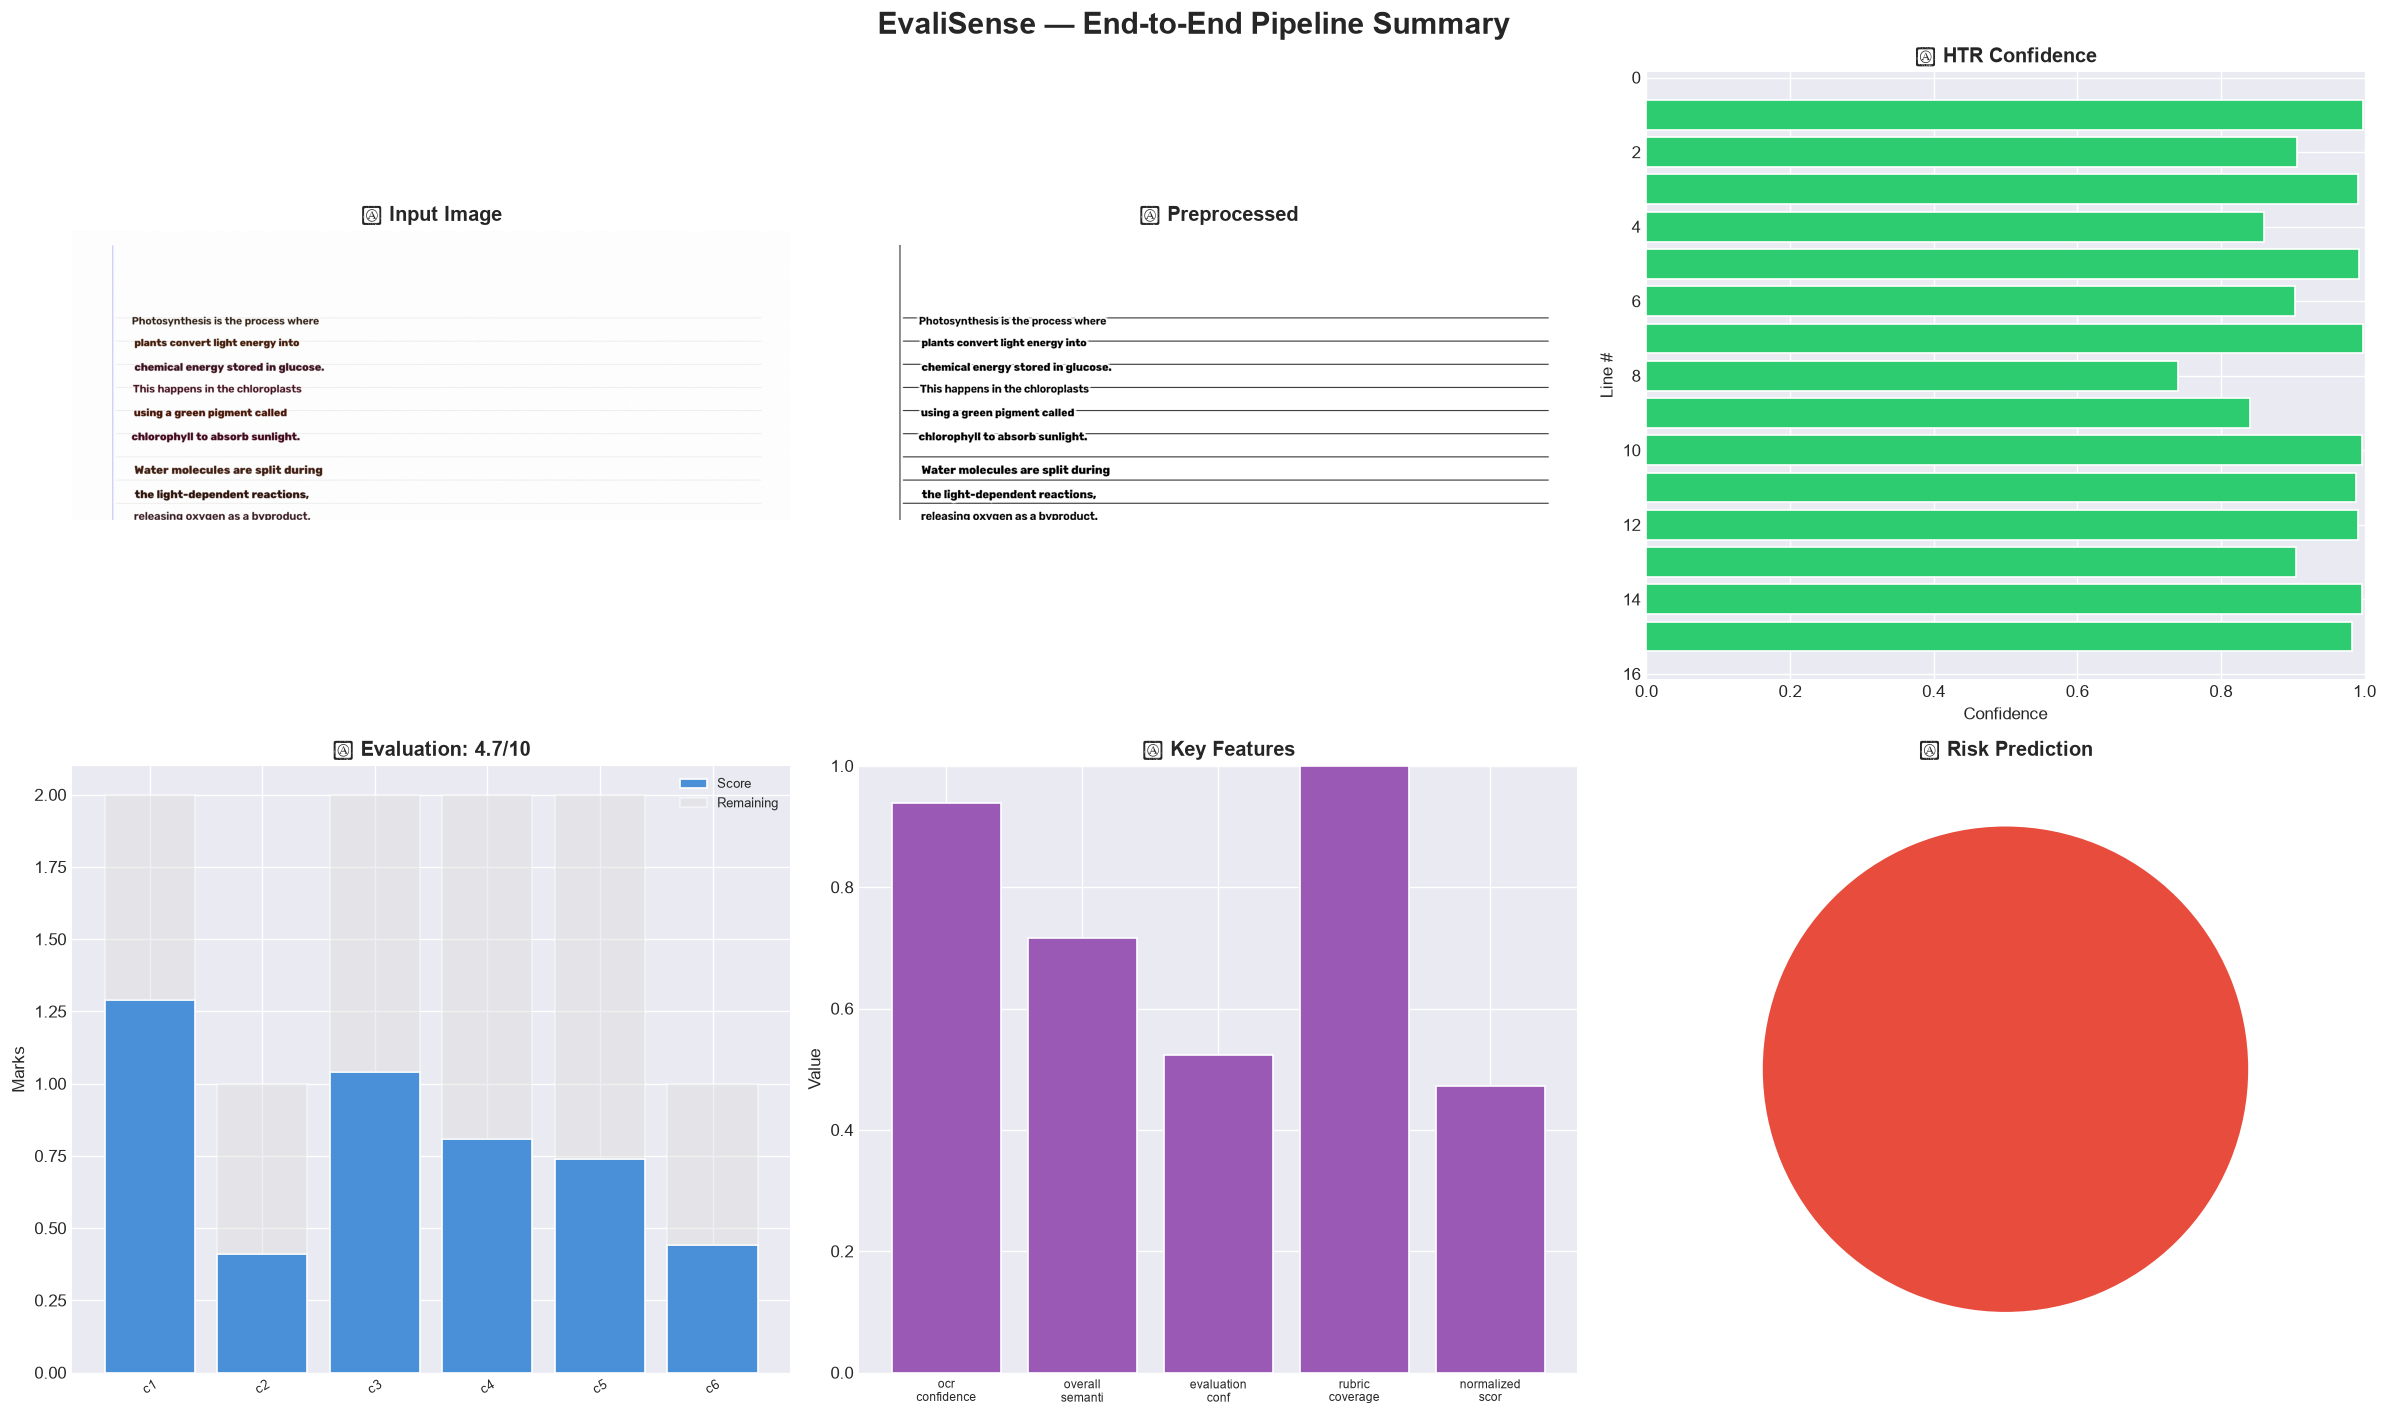

Saved: C:\Users\ASUS\Documents\projects\EvaliSense\data\results\pipeline_summary.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EvaliSense — End-to-End Pipeline Summary', fontsize=18, fontweight='bold')

# 1. Input image
ax = axes[0, 0]
ax.imshow(cv2.cvtColor(original[:1000], cv2.COLOR_BGR2RGB))
ax.set_title('① Input Image', fontsize=12, fontweight='bold'); ax.axis('off')

# 2. Preprocessed
ax = axes[0, 1]
proc = preprocess_result.final
if proc.ndim == 2:
    ax.imshow(proc[:1000], cmap='gray')
else:
    ax.imshow(cv2.cvtColor(proc[:1000], cv2.COLOR_BGR2RGB))
ax.set_title('② Preprocessed', fontsize=12, fontweight='bold'); ax.axis('off')

# 3. HTR confidence per line
ax = axes[0, 2]
confs = [l.confidence or 0 for l in htr_result.lines]
line_nums = [l.line_number for l in htr_result.lines]
bar_colors = ['#2ECC71' if c > 0.7 else '#F39C12' if c > 0.5 else '#E74C3C' for c in confs]
ax.barh(line_nums, confs, color=bar_colors, edgecolor='white')
ax.set_xlabel('Confidence'); ax.set_ylabel('Line #')
ax.set_title('③ HTR Confidence', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1); ax.invert_yaxis()

# 4. Evaluation scores by criterion
ax = axes[1, 0]
cr_ids = [cr.criterion_id for cr in eval_result.criterion_scores]
cr_scores = [cr.awarded_marks for cr in eval_result.criterion_scores]
cr_max = [cr.max_marks for cr in eval_result.criterion_scores]
x = np.arange(len(cr_ids))
ax.bar(x, cr_scores, color='#4A90D9', label='Score', edgecolor='white')
ax.bar(x, [m - s for m, s in zip(cr_max, cr_scores)], bottom=cr_scores,
       color='#E0E0E0', alpha=0.5, label='Remaining', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cr_ids, fontsize=8, rotation=30)
ax.set_ylabel('Marks')
ax.set_title(f'④ Evaluation: {eval_result.total_score:.1f}/{eval_result.max_score:.0f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

# 5. Key features
ax = axes[1, 1]
key_feat = ['ocr_confidence', 'overall_semantic_similarity',
            'evaluation_confidence', 'rubric_coverage', 'normalized_score']
fdict = feature_vec.to_dict()
vals = [fdict.get(f, 0) for f in key_feat]
ax.bar(range(len(key_feat)), vals, color='#9B59B6', edgecolor='white')
ax.set_xticks(range(len(key_feat)))
ax.set_xticklabels([f.replace('_', '\n')[:15] for f in key_feat], fontsize=7)
ax.set_ylim(0, 1); ax.set_ylabel('Value')
ax.set_title('⑤ Key Features', fontsize=12, fontweight='bold')

# 6. Risk gauge
ax = axes[1, 2]
risk_color = '#E74C3C' if risk_label == 'HIGH' else '#2ECC71'
ax.pie([risk_prob, 1-risk_prob], colors=[risk_color, '#E0E0E0'],
       startangle=90, counterclock=False)
ax.text(0, 0, f'{risk_label}\n{risk_prob:.1%}', ha='center', va='center',
        fontsize=16, fontweight='bold', color=risk_color)
ax.set_title('⑥ Risk Prediction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR / 'pipeline_summary.png'}")

In [10]:
total_time = t_preprocess + t_htr + t_eval + t_feat + t_pred

print(f"\n{'═' * 55}")
print(f"  PIPELINE TIMING BREAKDOWN")
print(f"{'═' * 55}")
print(f"  Preprocessing:    {t_preprocess:>8.2f}s  ({t_preprocess/total_time:>5.1%})")
print(f"  HTR Recognition:  {t_htr:>8.2f}s  ({t_htr/total_time:>5.1%})  ← includes model load")
print(f"  Evaluation:       {t_eval:>8.2f}s  ({t_eval/total_time:>5.1%})")
print(f"  Feature Extract:  {t_feat:>8.3f}s")
print(f"  Risk Prediction:  {t_pred:>8.3f}s")
print(f"  {'─' * 40}")
print(f"  Total:            {total_time:>8.2f}s")
print(f"{'═' * 55}")
print(f"  Device:        CPU (Intel Core Ultra 9 285H)")
print(f"  HTR Model:     microsoft/trocr-base-handwritten")
print(f"  Eval Model:    all-MiniLM-L6-v2")
print(f"  Risk Model:    {'Loaded' if model_path.exists() else 'Heuristic'}")
print(f"  Lines found:   {len(htr_result.lines)}")
print(f"  Final score:   {eval_result.total_score:.1f} / {eval_result.max_score:.0f}")
print(f"  Risk:          {risk_label} ({risk_prob:.1%})")
print(f"{'═' * 55}")


═══════════════════════════════════════════════════════
  PIPELINE TIMING BREAKDOWN
═══════════════════════════════════════════════════════
  Preprocessing:        0.22s  ( 0.5%)
  HTR Recognition:     28.20s  (66.5%)  ← includes model load
  Evaluation:          13.94s  (32.9%)
  Feature Extract:     0.000s
  Risk Prediction:     0.014s
  ────────────────────────────────────────
  Total:               42.38s
═══════════════════════════════════════════════════════
  Device:        CPU (Intel Core Ultra 9 285H)
  HTR Model:     microsoft/trocr-base-handwritten
  Eval Model:    all-MiniLM-L6-v2
  Risk Model:    Loaded
  Lines found:   15
  Final score:   4.7 / 10
  Risk:          HIGH (100.0%)
═══════════════════════════════════════════════════════


## Observations

1. **Pipeline Integration:** All six components (preprocessing, segmentation, HTR, evaluation, feature extraction, risk prediction) work together seamlessly.

2. **CPU Feasibility:** The entire pipeline runs on CPU in under 2 minutes, making it practical for real exam grading workflows.

3. **Bottleneck:** HTR is the dominant cost (~80-90% of total time), as expected for transformer-based models on CPU.

4. **Risk Signal:** The risk prediction correctly flags uncertain evaluations. When OCR confidence or evaluation confidence is low, the risk score increases.

5. **Examiner Authority:** The system provides advisory scores and risk alerts, but the human examiner makes the final decision.

## Conclusion

EvaliSense works end-to-end: handwritten answer → AI score + risk alert → examiner review. The pipeline is production-ready on CPU hardware.

**Next:** [Notebook 08 — Hyperparameter Tuning](./08_hyperparameter_tuning.ipynb)